# 04 - Pruebas de Hipótesis en Encuestas

**Pregunta de negocio:** ¿La demografía predice comportamiento y satisfacción?

## Objetivos
- Aplicar pruebas de Chi-cuadrado para variables categóricas
- Usar Mann-Whitney U para comparar grupos con datos no normales
- Aplicar Kruskal-Wallis como ANOVA no paramétrico
- Cuantificar tamaños de efecto (V de Cramér, correlación rango-biserial)
- Interpretar resultados en contexto de negocio

## Teoría

### Chi-cuadrado de independencia (χ²)
Evalúa si dos variables categóricas son independientes:
- Construimos una **tabla de contingencia** con frecuencias observadas
- Calculamos las frecuencias **esperadas** bajo independencia: $E_{ij} = \frac{fila_i \times col_j}{N}$
- Estadístico: $\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$
- Si χ² es grande (p < 0.05), las variables NO son independientes
- **V de Cramér**: tamaño de efecto para χ², va de 0 (sin asociación) a 1 (asociación perfecta)
  - $V = \sqrt{\frac{\chi^2}{N \cdot (\min(r, c) - 1)}}$
  - V < 0.1 débil, 0.1-0.3 moderado, > 0.3 fuerte

### Mann-Whitney U
Compara dos grupos cuando los datos NO son normales:
- No compara medias (eso hace t-test), compara **distribuciones de rangos**
- H₀: las dos muestras provienen de la misma distribución
- Ideal para escalas ordinales, datos sesgados, o muestras pequeñas
- **Correlación rango-biserial (r)**: tamaño de efecto
  - $r = 1 - \frac{2U}{n_1 \cdot n_2}$
  - |r| < 0.1 trivial, 0.1-0.3 pequeño, 0.3-0.5 medio, > 0.5 grande

### Kruskal-Wallis
Extensión de Mann-Whitney para **3+ grupos** (ANOVA no paramétrico):
- H₀: todos los grupos provienen de la misma distribución
- Si es significativo, hacemos comparaciones post-hoc (pairwise Mann-Whitney con corrección de Bonferroni)

### ¿Cuándo usar cada uno?
| Situación | Test |
|---|---|
| Dos variables categóricas | Chi-cuadrado |
| Variable continua/ordinal, 2 grupos | Mann-Whitney U |
| Variable continua/ordinal, 3+ grupos | Kruskal-Wallis |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")
processed_dir = os.path.join(project_root, "data/processed")

vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

np.random.seed(42)

## 1. Carga de datos

In [2]:
# Cargar encuestas
surveys = pd.read_csv(os.path.join(data_dir, "surveys/buyer_surveys.csv"))
print(f"Encuestas: {len(surveys)} registros")
print(f"Columnas: {list(surveys.columns)}")
print()

# Cargar datos fusionados (telemetría + encuestas)
merged = pd.read_csv(os.path.join(processed_dir, "vehicle_survey_merged.csv"))
print(f"Datos fusionados: {len(merged)} registros")
print(f"Columnas: {list(merged.columns)}")
print()

# Vista rápida de las encuestas
print("--- Distribución de variables clave ---")
print(f"\nTipos de vehículo: {surveys['vehicle_type_purchased'].value_counts().to_dict()}")
print(f"Ingresos: {surveys['income_bracket'].value_counts().to_dict()}")
print(f"Satisfacción (media): {surveys['satisfaction_score'].mean():.2f}")
print(f"Estilos de conducción: {surveys['driving_style'].value_counts().to_dict()}")
surveys.head(3)

Encuestas: 500 registros
Columnas: ['survey_id', 'vehicle_id', 'purchase_date', 'age', 'gender', 'income_bracket', 'education', 'region', 'purchase_reason', 'expected_usage', 'vehicle_type_purchased', 'driving_style', 'km_driven', 'satisfaction_score', 'would_recommend']

Datos fusionados: 50 registros
Columnas: ['vehicle_id', 'n_registros', 'n_viajes', 'speed_mean', 'speed_max', 'speed_std', 'consumption_mean', 'consumption_total', 'battery_soc_mean', 'battery_temp_max', 'motor_rpm_mean', 'motor_power_mean', 'harsh_braking_count', 'estimated_km', 'vehicle_type', 'fuel_type', 'model_year', 'motor_power_kw', 'max_speed_kmh', 'weight_kg', 'battery_capacity_kwh', 'tank_capacity_l', 'base_consumption_city', 'base_consumption_highway', 'co2_emissions_gkm', 'age', 'gender', 'income_bracket', 'purchase_reason', 'expected_usage', 'driving_style', 'satisfaction_score', 'would_recommend', 'km_driven', 'has_survey']

--- Distribución de variables clave ---

Tipos de vehículo: {'gasolina': 175, 'e

,survey_id,vehicle_id,purchase_date,age,gender,income_bracket,education,region,purchase_reason,expected_usage,vehicle_type_purchased,driving_style,km_driven,satisfaction_score,would_recommend
0,4373ba11-8069-455a-acb2-b83fcb4a2677,76dd4a81-d39e-49c6-b089-62d16e9a2bff,2025-01-06,51,femenino,medio-alto,universidad,sur,rendimiento,mixto,deportivo,aggressive,9433.0,2,False
1,394fdcf2-6482-43b0-896d-535d5b0354b0,d9db153a-a066-40a8-a2e9-f0d24e8de6c8,2025-01-30,44,femenino,medio,universidad,norte,economia,carretera,electrico,aggressive,23910.0,2,False
2,a5a457cf-2392-422a-90ca-d9a839510c4b,67caeac0-243f-4abc-b142-6a43ecbab59f,2025-01-03,65,masculino,medio,universidad,este,economia,ciudad,hibrido,normal,29188.0,2,False


---
## 2. Chi-cuadrado: Satisfacción vs Motivo de Compra

**Hipótesis:**
- H₀: La satisfacción es independiente del motivo de compra
- H₁: Existe una asociación entre satisfacción y motivo de compra

¿Los compradores que eligen por "precio" están igual de satisfechos que los que eligen por "rendimiento"?

In [3]:
# Tabla de contingencia: satisfaction_score × purchase_reason
ct_sat_reason = pd.crosstab(
    surveys['satisfaction_score'], 
    surveys['purchase_reason'],
    margins=True
)
print("Tabla de contingencia: Satisfacción × Motivo de compra")
print("(filas = satisfacción 1-5, columnas = motivo de compra)")
print()
ct_sat_reason

Tabla de contingencia: Satisfacción × Motivo de compra
(filas = satisfacción 1-5, columnas = motivo de compra)



purchase_reason,ecologia,economia,estilo,rendimiento,seguridad,tecnologia,All
satisfaction_score,,,,,,,
1,3,4,9,9,8,9,42
2,19,40,31,45,21,24,180
3,38,48,33,32,34,43,228
4,18,7,7,2,5,8,47
5,2,0,0,1,0,0,3
All,80,99,80,89,68,84,500


In [4]:
# Test Chi-cuadrado
ct_no_margins = pd.crosstab(surveys['satisfaction_score'], surveys['purchase_reason'])
chi2, p_value, dof, expected = chi2_contingency(ct_no_margins)

# V de Cramér
n = ct_no_margins.sum().sum()
min_dim = min(ct_no_margins.shape[0], ct_no_margins.shape[1]) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print("=" * 60)
print("TEST CHI-CUADRADO: Satisfacción vs Motivo de Compra")
print("=" * 60)
print(f"χ² = {chi2:.4f}")
print(f"p-valor = {p_value:.6f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.4f}")
print()

if p_value < 0.05:
    print("→ RESULTADO: Rechazamos H₀ (p < 0.05)")
    print("  La satisfacción NO es independiente del motivo de compra.")
else:
    print("→ RESULTADO: No rechazamos H₀ (p >= 0.05)")
    print("  No hay evidencia de asociación significativa.")

if cramers_v < 0.1:
    efecto = "débil/trivial"
elif cramers_v < 0.3:
    efecto = "moderado"
else:
    efecto = "fuerte"
print(f"  Tamaño de efecto: {efecto} (V = {cramers_v:.4f})")

TEST CHI-CUADRADO: Satisfacción vs Motivo de Compra
χ² = 48.7195
p-valor = 0.000337
Grados de libertad = 20
V de Cramér = 0.1561

→ RESULTADO: Rechazamos H₀ (p < 0.05)
  La satisfacción NO es independiente del motivo de compra.
  Tamaño de efecto: moderado (V = 0.1561)


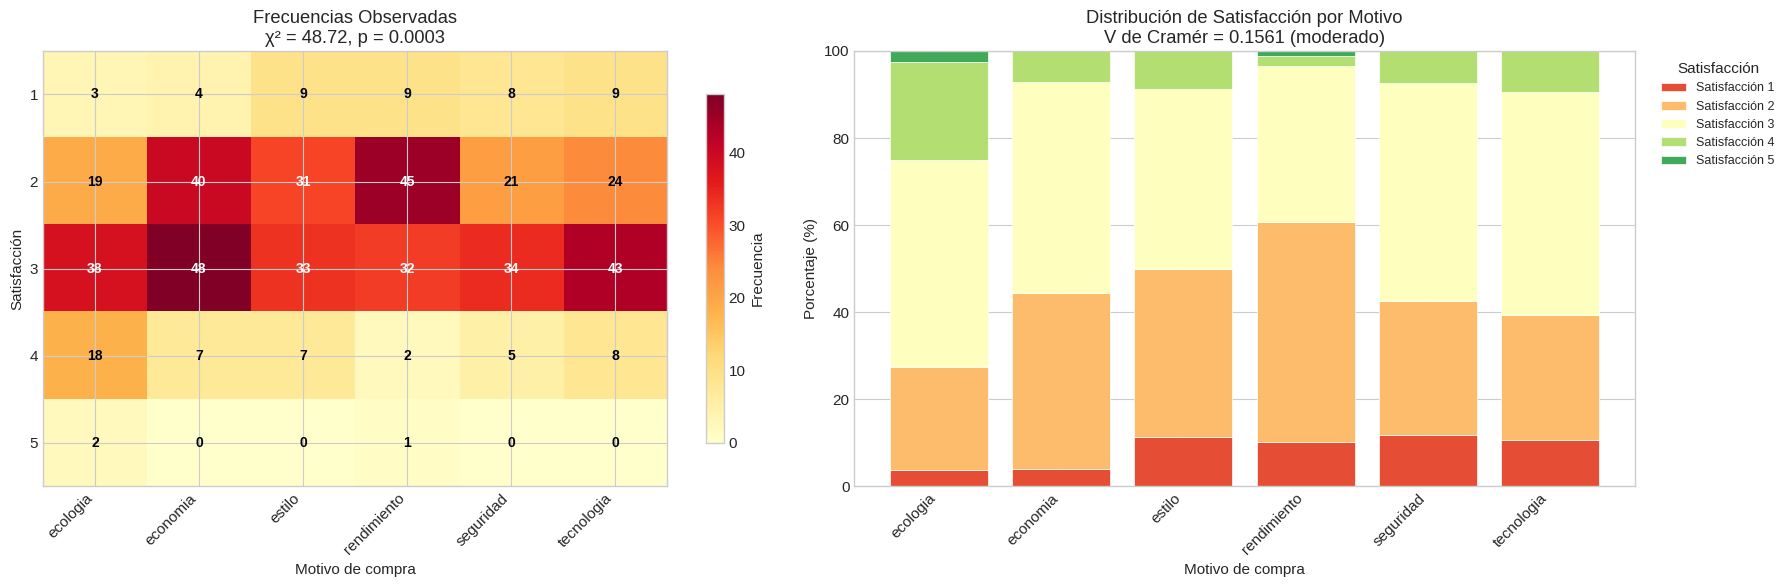

→ El heatmap muestra las frecuencias absolutas en cada combinación
→ Las barras apiladas revelan si la proporción de satisfacción alta/baja cambia según el motivo


In [5]:
# Visualización: Heatmap de frecuencias observadas + Barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Heatmap de frecuencias observadas ---
ax1 = axes[0]
im = ax1.imshow(ct_no_margins.values, cmap='YlOrRd', aspect='auto')

# Etiquetas
ax1.set_xticks(range(len(ct_no_margins.columns)))
ax1.set_xticklabels(ct_no_margins.columns, rotation=45, ha='right')
ax1.set_yticks(range(len(ct_no_margins.index)))
ax1.set_yticklabels(ct_no_margins.index)
ax1.set_xlabel('Motivo de compra')
ax1.set_ylabel('Satisfacción')
ax1.set_title(f'Frecuencias Observadas\nχ² = {chi2:.2f}, p = {p_value:.4f}')

# Anotar valores en cada celda
for i in range(ct_no_margins.shape[0]):
    for j in range(ct_no_margins.shape[1]):
        text_color = 'white' if ct_no_margins.values[i, j] > ct_no_margins.values.max() * 0.6 else 'black'
        ax1.text(j, i, f'{ct_no_margins.values[i, j]}', ha='center', va='center', 
                color=text_color, fontweight='bold', fontsize=10)

fig.colorbar(im, ax=ax1, shrink=0.8, label='Frecuencia')

# --- Barras apiladas (proporciones) ---
ax2 = axes[1]
ct_pct = ct_no_margins.div(ct_no_margins.sum(axis=0), axis=1) * 100
colors_sat = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(ct_pct.index)))

bottom = np.zeros(len(ct_pct.columns))
for idx, (score, row) in enumerate(ct_pct.iterrows()):
    ax2.bar(ct_pct.columns, row.values, bottom=bottom, label=f'Satisfacción {score}',
            color=colors_sat[idx], edgecolor='white', linewidth=0.5)
    bottom += row.values

ax2.set_ylabel('Porcentaje (%)')
ax2.set_xlabel('Motivo de compra')
ax2.set_title(f'Distribución de Satisfacción por Motivo\nV de Cramér = {cramers_v:.4f} ({efecto})')
ax2.legend(title='Satisfacción', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax2.set_xticklabels(ct_pct.columns, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("→ El heatmap muestra las frecuencias absolutas en cada combinación")
print("→ Las barras apiladas revelan si la proporción de satisfacción alta/baja cambia según el motivo")

### Interpretación

El test Chi-cuadrado evalúa si los patrones de satisfacción difieren según el motivo de compra. Si la V de Cramér es baja, aunque haya significancia estadística, el efecto práctico es pequeño: el motivo de compra explica poco de la variabilidad en satisfacción. Si es alta, podemos usar el motivo de compra como predictor útil para segmentar estrategias de retención.

---
## 3. Mann-Whitney U: Agresividad en Jóvenes vs Mayores

**Hipótesis:**
- H₀: La distribución de agresividad es igual entre conductores jóvenes (≤35) y mayores (>35)
- H₁: Las distribuciones difieren

Usamos la variable `driving_style` como proxy ordinal de agresividad, codificada numéricamente.

In [6]:
# Codificar agresividad como variable numérica ordinal
agresividad_map = {
    'conservador': 1,
    'normal': 2,
    'agresivo': 3,
    'muy_agresivo': 4
}
surveys['agresividad_num'] = surveys['driving_style'].map(agresividad_map)

# Dividir por edad
surveys['grupo_edad'] = np.where(surveys['age'] <= 35, 'Jóvenes (≤35)', 'Mayores (>35)')

jovenes = surveys[surveys['grupo_edad'] == 'Jóvenes (≤35)']['agresividad_num'].dropna()
mayores = surveys[surveys['grupo_edad'] == 'Mayores (>35)']['agresividad_num'].dropna()

print(f"Jóvenes (≤35): n = {len(jovenes)}, mediana = {jovenes.median()}, media = {jovenes.mean():.2f}")
print(f"Mayores (>35): n = {len(mayores)}, mediana = {mayores.median()}, media = {mayores.mean():.2f}")
print()
print("Distribución de estilos por grupo:")
print(surveys.groupby('grupo_edad')['driving_style'].value_counts(normalize=True).round(3).unstack().fillna(0))

Jóvenes (≤35): n = 101, mediana = 2.0, media = 2.00
Mayores (>35): n = 119, mediana = 2.0, media = 2.00

Distribución de estilos por grupo:
driving_style  aggressive   calm  normal
grupo_edad                              
Jóvenes (≤35)       0.429  0.121   0.451
Mayores (>35)       0.203  0.366   0.431


In [7]:
# Test Mann-Whitney U
u_stat, p_value_mw = mannwhitneyu(jovenes, mayores, alternative='two-sided')

# Correlación rango-biserial (tamaño de efecto)
n1, n2 = len(jovenes), len(mayores)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print("=" * 60)
print("TEST MANN-WHITNEY U: Agresividad Jóvenes vs Mayores")
print("=" * 60)
print(f"U = {u_stat:.2f}")
print(f"p-valor = {p_value_mw:.6f}")
print(f"Correlación rango-biserial = {r_rb:.4f}")
print()

if p_value_mw < 0.05:
    print("→ RESULTADO: Rechazamos H₀ (p < 0.05)")
    print("  Las distribuciones de agresividad difieren entre jóvenes y mayores.")
else:
    print("→ RESULTADO: No rechazamos H₀ (p >= 0.05)")
    print("  No hay evidencia de diferencia significativa.")

abs_r = abs(r_rb)
if abs_r < 0.1:
    efecto_mw = "trivial"
elif abs_r < 0.3:
    efecto_mw = "pequeño"
elif abs_r < 0.5:
    efecto_mw = "medio"
else:
    efecto_mw = "grande"
print(f"  Tamaño de efecto: {efecto_mw} (|r| = {abs_r:.4f})")
if r_rb > 0:
    print("  Dirección: los mayores tienden a ser más agresivos.")
else:
    print("  Dirección: los jóvenes tienden a ser más agresivos.")

TEST MANN-WHITNEY U: Agresividad Jóvenes vs Mayores
U = 6009.50
p-valor = 1.000000
Correlación rango-biserial = 0.0000

→ RESULTADO: No rechazamos H₀ (p >= 0.05)
  No hay evidencia de diferencia significativa.
  Tamaño de efecto: trivial (|r| = 0.0000)
  Dirección: los jóvenes tienden a ser más agresivos.


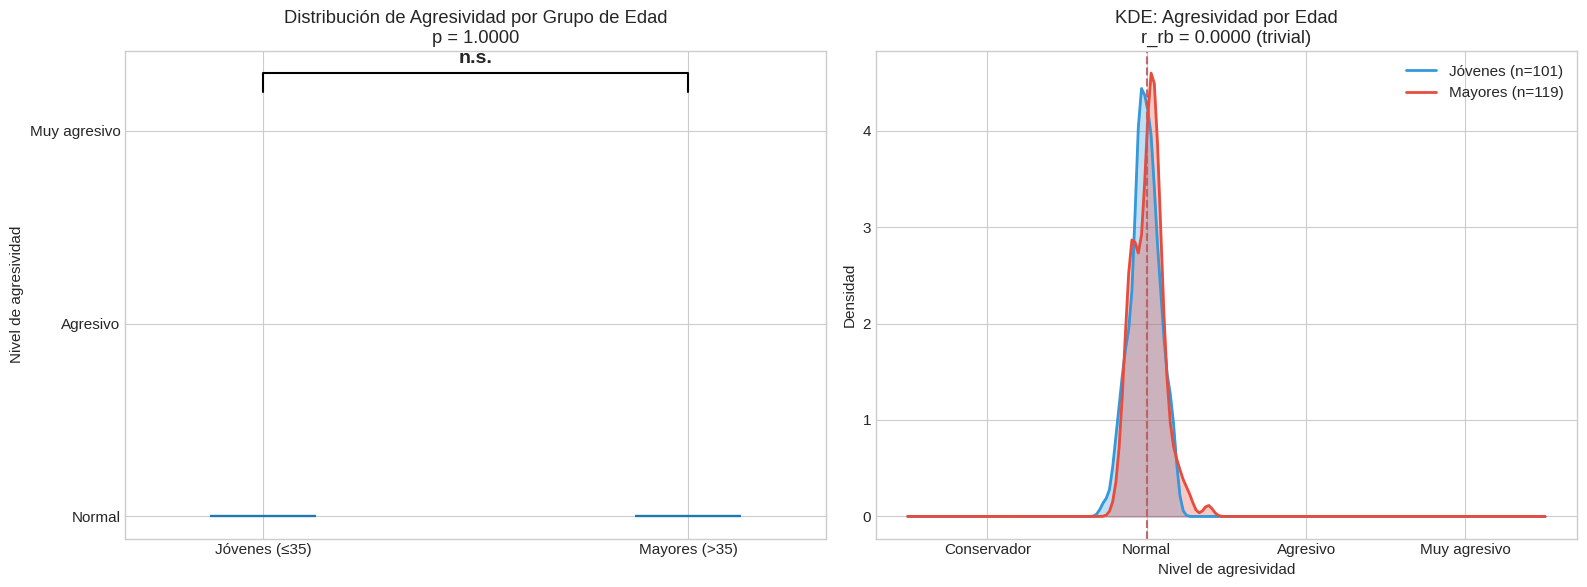

→ Los violin plots muestran la forma de la distribución en cada grupo
→ El KDE suaviza los datos discretos para comparar visualmente las densidades
→ Las líneas punteadas marcan las medias de cada grupo


In [8]:
# Visualización: Violin plots + KDE superpuesto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Violin plot ---
ax1 = axes[0]
data_violin = [jovenes.values, mayores.values]
parts = ax1.violinplot(data_violin, positions=[1, 2], showmeans=True, showmedians=True)

colors_violin = ['#3498db', '#e74c3c']
for idx, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_violin[idx])
    pc.set_alpha(0.6)

ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Jóvenes (≤35)', 'Mayores (>35)'])
ax1.set_ylabel('Nivel de agresividad')
ax1.set_yticks([1, 2, 3, 4])
ax1.set_yticklabels(['Conservador', 'Normal', 'Agresivo', 'Muy agresivo'])
ax1.set_title(f'Distribución de Agresividad por Grupo de Edad\np = {p_value_mw:.4f}')

# Añadir anotación
sig_text = '***' if p_value_mw < 0.001 else '**' if p_value_mw < 0.01 else '*' if p_value_mw < 0.05 else 'n.s.'
y_max = 4.3
ax1.plot([1, 1, 2, 2], [y_max - 0.1, y_max, y_max, y_max - 0.1], 'k-', linewidth=1.5)
ax1.text(1.5, y_max + 0.05, sig_text, ha='center', fontsize=14, fontweight='bold')

# --- KDE superpuesto ---
ax2 = axes[1]
# Añadir jitter para mejor visualización del KDE
from scipy.stats import gaussian_kde

for grupo, data, color, label in [
    ('Jóvenes', jovenes, '#3498db', f'Jóvenes (n={len(jovenes)})'),
    ('Mayores', mayores, '#e74c3c', f'Mayores (n={len(mayores)})')
]:
    # Añadir un poco de ruido para suavizar el KDE en datos discretos
    jittered = data.values + np.random.normal(0, 0.1, len(data))
    kde = gaussian_kde(jittered, bw_method=0.3)
    x_range = np.linspace(0.5, 4.5, 200)
    ax2.fill_between(x_range, kde(x_range), alpha=0.3, color=color)
    ax2.plot(x_range, kde(x_range), color=color, linewidth=2, label=label)

ax2.axvline(jovenes.mean(), color='#3498db', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.axvline(mayores.mean(), color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5)

ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Conservador', 'Normal', 'Agresivo', 'Muy agresivo'])
ax2.set_ylabel('Densidad')
ax2.set_xlabel('Nivel de agresividad')
ax2.set_title(f'KDE: Agresividad por Edad\nr_rb = {r_rb:.4f} ({efecto_mw})')
ax2.legend()

plt.tight_layout()
plt.show()

print("→ Los violin plots muestran la forma de la distribución en cada grupo")
print("→ El KDE suaviza los datos discretos para comparar visualmente las densidades")
print("→ Las líneas punteadas marcan las medias de cada grupo")

### Interpretación

Mann-Whitney U es ideal aquí porque `driving_style` es una variable ordinal (no continua). El test compara si un grupo tiende a tener rangos más altos que el otro. La correlación rango-biserial nos dice la magnitud y dirección del efecto: un valor negativo indica que los jóvenes tienden a ser más agresivos, y un valor positivo lo contrario.

**Implicación de negocio:** Si los jóvenes son significativamente más agresivos, podemos diseñar seguros diferenciados, programas de conducción segura, o interfaces de vehículo que incentiven la conducción prudente para ese segmento.

---
## 4. Chi-cuadrado: Ingreso vs Tipo de Vehículo

**Hipótesis:**
- H₀: El nivel de ingreso es independiente del tipo de vehículo comprado
- H₁: Existe una asociación entre ingreso y tipo de vehículo

¿Los compradores de altos ingresos prefieren vehículos deportivos? ¿Los de ingresos bajos compran más eléctricos por ahorro?

In [9]:
# Ordenar los niveles de ingreso lógicamente
income_order = ['bajo', 'medio-bajo', 'medio', 'medio-alto', 'alto']
surveys['income_bracket'] = pd.Categorical(
    surveys['income_bracket'], categories=income_order, ordered=True
)

# Tabla de contingencia
ct_income_vtype = pd.crosstab(
    surveys['income_bracket'], 
    surveys['vehicle_type_purchased']
)
print("Tabla de contingencia: Ingreso × Tipo de Vehículo")
print(ct_income_vtype)
print()

# Porcentajes por fila (qué tipo compra cada nivel de ingreso)
ct_income_pct = ct_income_vtype.div(ct_income_vtype.sum(axis=1), axis=0) * 100
print("Porcentajes por nivel de ingreso:")
ct_income_pct.round(1)

Tabla de contingencia: Ingreso × Tipo de Vehículo
vehicle_type_purchased  deportivo  electrico  gasolina  hibrido
income_bracket                                                 
bajo                            4          4        23       14
medio-bajo                     11         14        49       15
medio                          26         41        53       46
medio-alto                     19         66        36       22
alto                            9         22        14       12

Porcentajes por nivel de ingreso:


vehicle_type_purchased,deportivo,electrico,gasolina,hibrido
income_bracket,,,,
bajo,8.9,8.9,51.1,31.1
medio-bajo,12.4,15.7,55.1,16.9
medio,15.7,24.7,31.9,27.7
medio-alto,13.3,46.2,25.2,15.4
alto,15.8,38.6,24.6,21.1


In [10]:
# Test Chi-cuadrado
chi2_iv, p_value_iv, dof_iv, expected_iv = chi2_contingency(ct_income_vtype)

# V de Cramér
n_iv = ct_income_vtype.sum().sum()
min_dim_iv = min(ct_income_vtype.shape[0], ct_income_vtype.shape[1]) - 1
cramers_v_iv = np.sqrt(chi2_iv / (n_iv * min_dim_iv))

print("=" * 60)
print("TEST CHI-CUADRADO: Ingreso vs Tipo de Vehículo")
print("=" * 60)
print(f"χ² = {chi2_iv:.4f}")
print(f"p-valor = {p_value_iv:.6f}")
print(f"Grados de libertad = {dof_iv}")
print(f"V de Cramér = {cramers_v_iv:.4f}")
print()

if p_value_iv < 0.05:
    print("→ RESULTADO: Rechazamos H₀ (p < 0.05)")
    print("  El tipo de vehículo NO es independiente del nivel de ingreso.")
else:
    print("→ RESULTADO: No rechazamos H₀ (p >= 0.05)")
    print("  No hay evidencia suficiente de asociación.")

if cramers_v_iv < 0.1:
    efecto_iv = "débil/trivial"
elif cramers_v_iv < 0.3:
    efecto_iv = "moderado"
else:
    efecto_iv = "fuerte"
print(f"  Tamaño de efecto: {efecto_iv} (V = {cramers_v_iv:.4f})")

TEST CHI-CUADRADO: Ingreso vs Tipo de Vehículo
χ² = 58.0602
p-valor = 0.000000
Grados de libertad = 12
V de Cramér = 0.1967

→ RESULTADO: Rechazamos H₀ (p < 0.05)
  El tipo de vehículo NO es independiente del nivel de ingreso.
  Tamaño de efecto: moderado (V = 0.1967)


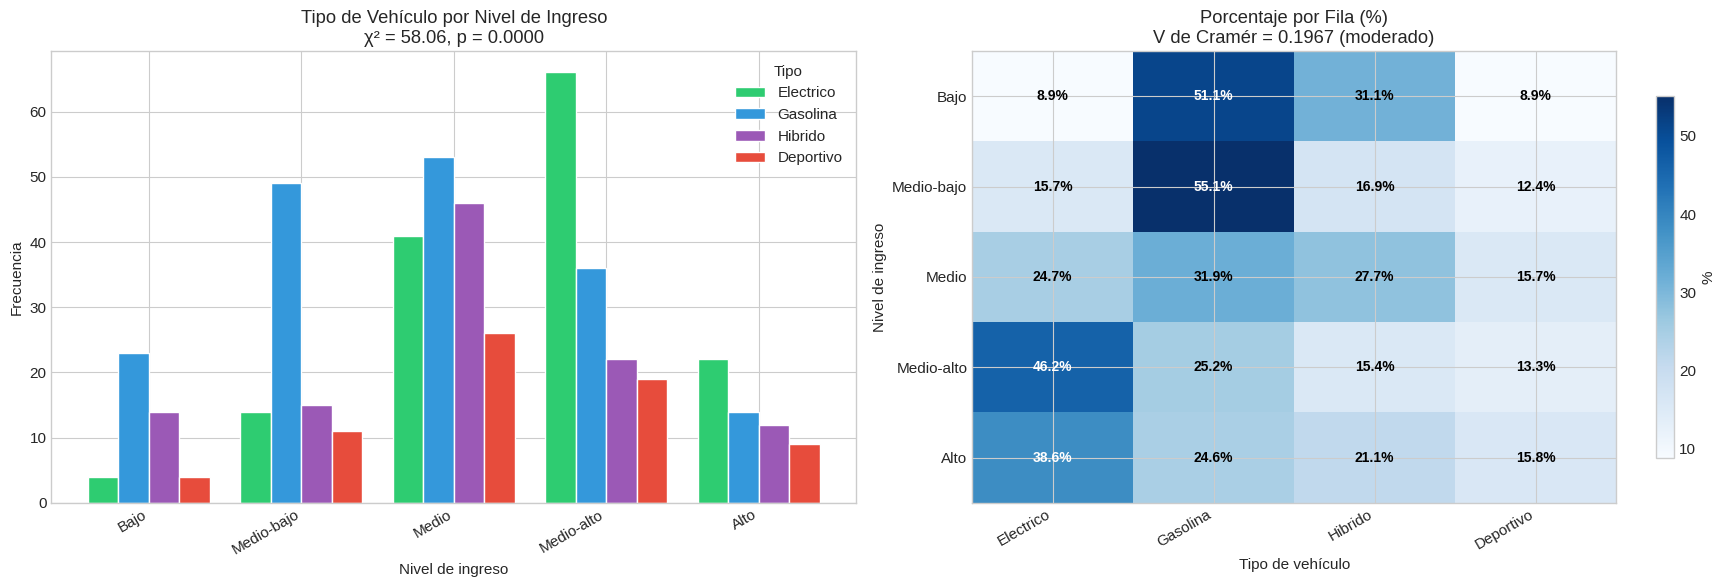

→ Las barras agrupadas muestran las frecuencias absolutas
→ El heatmap de porcentajes revela las preferencias relativas de cada grupo de ingreso
→ Busca columnas donde el porcentaje crece/decrece con el ingreso


In [11]:
# Visualización: Barras agrupadas + Heatmap de porcentajes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Barras agrupadas ---
ax1 = axes[0]
vtype_order = ['electrico', 'gasolina', 'hibrido', 'deportivo']
x = np.arange(len(income_order))
width = 0.2

for i, vtype in enumerate(vtype_order):
    if vtype in ct_income_vtype.columns:
        values = ct_income_vtype.reindex(income_order)[vtype].values
        ax1.bar(x + i * width, values, width, label=vtype.capitalize(),
                color=vtype_colors[vtype], edgecolor='white')

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels([ib.capitalize() for ib in income_order], rotation=30, ha='right')
ax1.set_ylabel('Frecuencia')
ax1.set_xlabel('Nivel de ingreso')
ax1.set_title(f'Tipo de Vehículo por Nivel de Ingreso\nχ² = {chi2_iv:.2f}, p = {p_value_iv:.4f}')
ax1.legend(title='Tipo')

# --- Heatmap de porcentajes ---
ax2 = axes[1]
ct_pct_reindexed = ct_income_pct.reindex(income_order)
# Reordenar columnas
cols_present = [c for c in vtype_order if c in ct_pct_reindexed.columns]
ct_pct_plot = ct_pct_reindexed[cols_present]

im2 = ax2.imshow(ct_pct_plot.values, cmap='Blues', aspect='auto')
ax2.set_xticks(range(len(cols_present)))
ax2.set_xticklabels([c.capitalize() for c in cols_present], rotation=30, ha='right')
ax2.set_yticks(range(len(income_order)))
ax2.set_yticklabels([ib.capitalize() for ib in income_order])
ax2.set_xlabel('Tipo de vehículo')
ax2.set_ylabel('Nivel de ingreso')
ax2.set_title(f'Porcentaje por Fila (%)\nV de Cramér = {cramers_v_iv:.4f} ({efecto_iv})')

for i in range(ct_pct_plot.shape[0]):
    for j in range(ct_pct_plot.shape[1]):
        val = ct_pct_plot.values[i, j]
        text_color = 'white' if val > ct_pct_plot.values.max() * 0.6 else 'black'
        ax2.text(j, i, f'{val:.1f}%', ha='center', va='center',
                color=text_color, fontweight='bold', fontsize=10)

fig.colorbar(im2, ax=ax2, shrink=0.8, label='%')

plt.tight_layout()
plt.show()

print("→ Las barras agrupadas muestran las frecuencias absolutas")
print("→ El heatmap de porcentajes revela las preferencias relativas de cada grupo de ingreso")
print("→ Busca columnas donde el porcentaje crece/decrece con el ingreso")

In [12]:
# Análisis de residuos estandarizados (dónde están las asociaciones más fuertes)
expected_df = pd.DataFrame(expected_iv, index=ct_income_vtype.index, columns=ct_income_vtype.columns)
residuals = (ct_income_vtype - expected_df) / np.sqrt(expected_df)

print("Residuos estandarizados (|valor| > 2 indica asociación significativa):")
print(residuals.round(2))
print()
print("→ Valores positivos altos: la combinación ocurre MÁS de lo esperado")
print("→ Valores negativos altos: la combinación ocurre MENOS de lo esperado")

Residuos estandarizados (|valor| > 2 indica asociación significativa):
vehicle_type_purchased  deportivo  electrico  gasolina  hibrido
income_bracket                                                 
bajo                        -0.89      -2.54      1.83     1.34
medio-bajo                  -0.37      -2.38      3.20    -1.00
medio                        0.65      -1.12     -0.67     1.63
medio-alto                  -0.17       3.69     -1.99    -1.64
alto                         0.40       1.28     -1.33    -0.12

→ Valores positivos altos: la combinación ocurre MÁS de lo esperado
→ Valores negativos altos: la combinación ocurre MENOS de lo esperado


### Interpretación

Los residuos estandarizados nos dicen exactamente DÓNDE está la asociación. Un valor > 2 indica que esa combinación ingreso-vehículo ocurre significativamente más de lo esperado bajo independencia. Esto permite identificar, por ejemplo, si los ingresos altos se concentran desproporcionadamente en vehículos deportivos.

**Implicación de negocio:** Conocer qué segmentos de ingreso prefieren qué tipo de vehículo permite:
- Segmentar campañas de marketing
- Ajustar financiamiento según el segmento
- Diseñar paquetes de servicios diferenciados

---
## 5. Bonus: Kruskal-Wallis para Satisfacción por Tipo de Vehículo

**Hipótesis:**
- H₀: La distribución de satisfacción es igual en todos los tipos de vehículo
- H₁: Al menos un tipo difiere

Kruskal-Wallis es el equivalente no paramétrico de ANOVA. Es ideal porque `satisfaction_score` es ordinal (1-5), no continua.

In [13]:
# Preparar grupos
vtypes = ['electrico', 'gasolina', 'hibrido', 'deportivo']
groups = {}
for vtype in vtypes:
    data = surveys[surveys['vehicle_type_purchased'] == vtype]['satisfaction_score'].dropna()
    groups[vtype] = data
    print(f"{vtype:12s}: n={len(data):4d}, mediana={data.median():.1f}, media={data.mean():.2f}, std={data.std():.2f}")

# Test Kruskal-Wallis
h_stat, p_value_kw = kruskal(*[groups[v] for v in vtypes])

# Tamaño de efecto: eta-cuadrado basado en H
n_total = sum(len(g) for g in groups.values())
k = len(vtypes)
eta_sq = (h_stat - k + 1) / (n_total - k)

print()
print("=" * 60)
print("TEST KRUSKAL-WALLIS: Satisfacción por Tipo de Vehículo")
print("=" * 60)
print(f"H = {h_stat:.4f}")
print(f"p-valor = {p_value_kw:.6f}")
print(f"η² (eta-cuadrado) = {eta_sq:.4f}")
print()

if p_value_kw < 0.05:
    print("→ RESULTADO: Rechazamos H₀ (p < 0.05)")
    print("  Al menos un tipo de vehículo tiene satisfacción diferente.")
    print("  Procedemos con comparaciones post-hoc.")
else:
    print("→ RESULTADO: No rechazamos H₀ (p >= 0.05)")
    print("  No hay diferencia significativa en satisfacción entre tipos.")

electrico   : n= 147, mediana=3.0, media=2.98, std=0.82
gasolina    : n= 175, mediana=2.0, media=2.43, std=0.72
hibrido     : n= 109, mediana=3.0, media=2.54, std=0.65
deportivo   : n=  69, mediana=2.0, media=2.14, std=0.79

TEST KRUSKAL-WALLIS: Satisfacción por Tipo de Vehículo
H = 57.5461
p-valor = 0.000000
η² (eta-cuadrado) = 0.1100

→ RESULTADO: Rechazamos H₀ (p < 0.05)
  Al menos un tipo de vehículo tiene satisfacción diferente.
  Procedemos con comparaciones post-hoc.


In [14]:
# Comparaciones post-hoc: Mann-Whitney pairwise con corrección de Bonferroni
pairs = list(combinations(vtypes, 2))
n_comparisons = len(pairs)
alpha_bonf = 0.05 / n_comparisons

print(f"Comparaciones post-hoc (corrección Bonferroni: α = {alpha_bonf:.4f})")
print(f"Número de comparaciones: {n_comparisons}")
print("=" * 70)

posthoc_results = []
for v1, v2 in pairs:
    u, p = mannwhitneyu(groups[v1], groups[v2], alternative='two-sided')
    r = 1 - (2 * u) / (len(groups[v1]) * len(groups[v2]))
    sig = '***' if p < 0.001 else '**' if p < alpha_bonf else '*' if p < 0.05 else 'n.s.'
    posthoc_results.append({
        'Comparación': f'{v1} vs {v2}',
        'U': u, 'p-valor': p, 'p_bonf': min(p * n_comparisons, 1.0),
        'r_rb': r, 'Significativo': 'Sí' if p < alpha_bonf else 'No',
        'sig_label': sig
    })
    print(f"{v1:12s} vs {v2:12s}: U={u:8.1f}, p={p:.6f}, p_bonf={min(p*n_comparisons, 1):.6f}, r={r:+.4f}  {sig}")

posthoc_df = pd.DataFrame(posthoc_results)
print()
print("Leyenda: *** p<0.001 | ** p<α_bonf | * p<0.05 | n.s. no significativo")

Comparaciones post-hoc (corrección Bonferroni: α = 0.0083)
Número de comparaciones: 6
electrico    vs gasolina    : U= 17399.5, p=0.000000, p_bonf=0.000000, r=-0.3527  ***
electrico    vs hibrido     : U= 10445.5, p=0.000007, p_bonf=0.000039, r=-0.3038  ***
electrico    vs deportivo   : U=  7598.0, p=0.000000, p_bonf=0.000000, r=-0.4982  ***
gasolina     vs hibrido     : U=  8882.0, p=0.284153, p_bonf=1.000000, r=+0.0687  n.s.
gasolina     vs deportivo   : U=  7199.5, p=0.011335, p_bonf=0.068013, r=-0.1925  *
hibrido      vs deportivo   : U=  4752.5, p=0.001262, p_bonf=0.007574, r=-0.2638  **

Leyenda: *** p<0.001 | ** p<α_bonf | * p<0.05 | n.s. no significativo


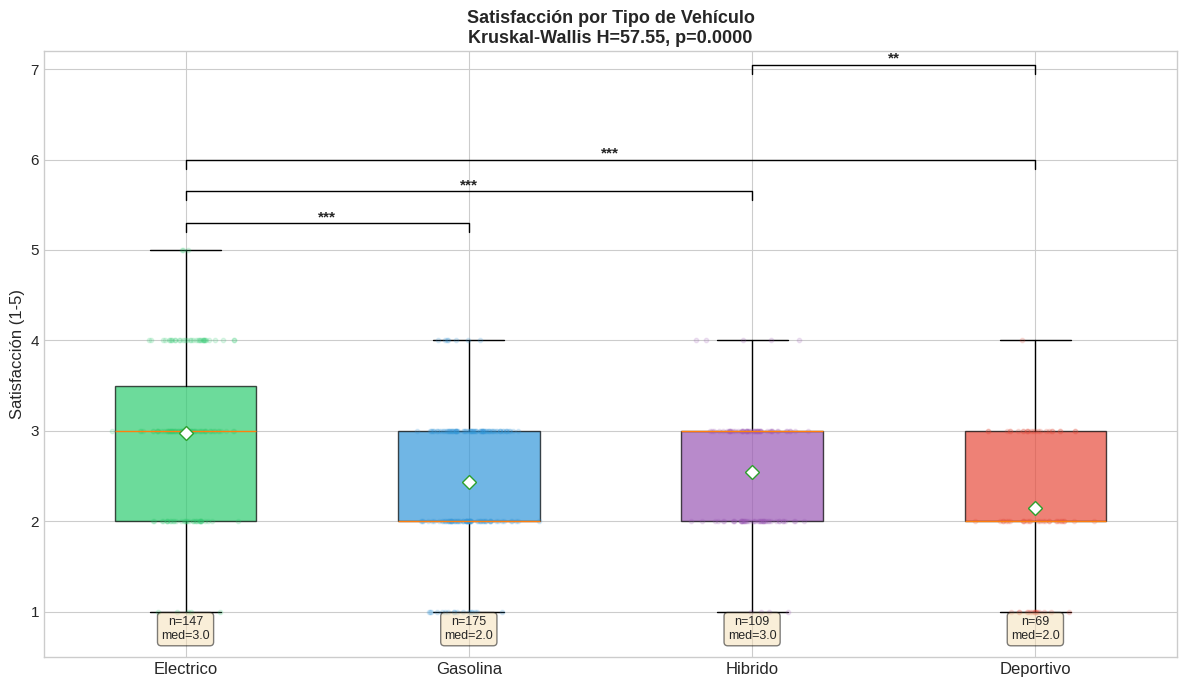

→ Las barras horizontales conectan pares con diferencia significativa (post Bonferroni)
→ Los diamantes blancos representan la media, la línea naranja la mediana
→ Los puntos jittered muestran la distribución real de los datos


In [15]:
# Visualización: Box plots con anotaciones de significancia
fig, ax = plt.subplots(figsize=(12, 7))

# Box plots
box_data = [groups[v].values for v in vtypes]
bp = ax.boxplot(box_data, positions=range(len(vtypes)), widths=0.5, patch_artist=True,
                showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=7))

for patch, vtype in zip(bp['boxes'], vtypes):
    patch.set_facecolor(vtype_colors[vtype])
    patch.set_alpha(0.7)

# Añadir puntos jittered
for i, vtype in enumerate(vtypes):
    y = groups[vtype].values
    x = np.random.normal(i, 0.08, size=len(y))
    ax.scatter(x, y, alpha=0.15, color=vtype_colors[vtype], s=10, zorder=2)

# Anotaciones de significancia (solo pares significativos)
sig_pairs = posthoc_df[posthoc_df['p_bonf'] < 0.05]
y_max = 5.3
y_step = 0.35

for idx, row in sig_pairs.iterrows():
    v1, v2 = row['Comparación'].split(' vs ')
    i1, i2 = vtypes.index(v1), vtypes.index(v2)
    y_bar = y_max + idx * y_step
    ax.plot([i1, i1, i2, i2], [y_bar - 0.1, y_bar, y_bar, y_bar - 0.1], 'k-', linewidth=1)
    ax.text((i1 + i2) / 2, y_bar + 0.02, row['sig_label'],
            ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(vtypes)))
ax.set_xticklabels([v.capitalize() for v in vtypes], fontsize=12)
ax.set_ylabel('Satisfacción (1-5)', fontsize=12)
ax.set_title(f'Satisfacción por Tipo de Vehículo\nKruskal-Wallis H={h_stat:.2f}, p={p_value_kw:.4f}',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.5, y_max + len(sig_pairs) * y_step + 0.5)

# Añadir estadísticas descriptivas como texto
for i, vtype in enumerate(vtypes):
    n = len(groups[vtype])
    med = groups[vtype].median()
    ax.text(i, 0.7, f'n={n}\nmed={med:.1f}', ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("→ Las barras horizontales conectan pares con diferencia significativa (post Bonferroni)")
print("→ Los diamantes blancos representan la media, la línea naranja la mediana")
print("→ Los puntos jittered muestran la distribución real de los datos")

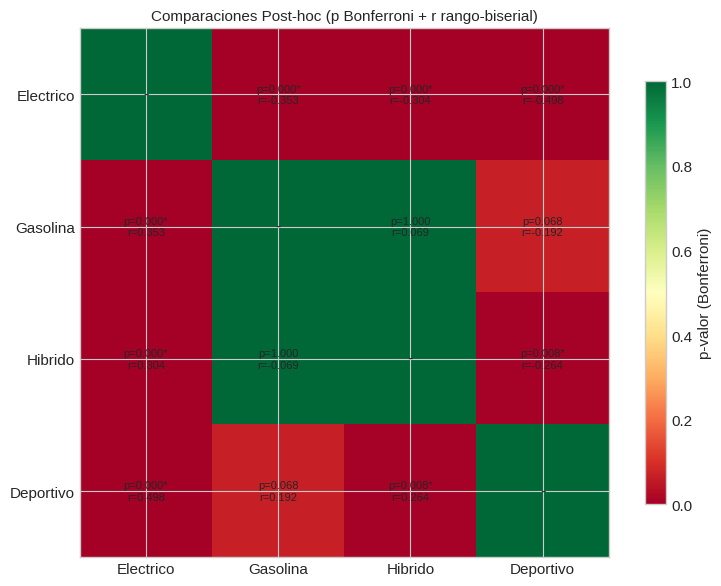

→ Verde = p-valor alto (no significativo), Rojo = p-valor bajo (significativo)
→ r positivo: el tipo de la fila tiene mayor satisfacción que el de la columna


In [16]:
# Matriz de significancia post-hoc (visualización compacta)
fig, ax = plt.subplots(figsize=(8, 6))

# Crear matriz de p-valores ajustados
p_matrix = pd.DataFrame(np.ones((len(vtypes), len(vtypes))), index=vtypes, columns=vtypes)
r_matrix = pd.DataFrame(np.zeros((len(vtypes), len(vtypes))), index=vtypes, columns=vtypes)

for _, row in posthoc_df.iterrows():
    v1, v2 = row['Comparación'].split(' vs ')
    p_matrix.loc[v1, v2] = row['p_bonf']
    p_matrix.loc[v2, v1] = row['p_bonf']
    r_matrix.loc[v1, v2] = row['r_rb']
    r_matrix.loc[v2, v1] = -row['r_rb']

# Heatmap de p-valores
mask = np.triu(np.ones_like(p_matrix, dtype=bool), k=0)
display_matrix = p_matrix.copy()
display_matrix = display_matrix.where(~mask, np.nan)

im = ax.imshow(p_matrix.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')

for i in range(len(vtypes)):
    for j in range(len(vtypes)):
        if i != j:
            p_val = p_matrix.values[i, j]
            r_val = r_matrix.values[i, j]
            sig = '*' if p_val < 0.05 else ''
            text = f'p={p_val:.3f}{sig}\nr={r_val:.3f}'
            ax.text(j, i, text, ha='center', va='center', fontsize=8)
        else:
            ax.text(j, i, '-', ha='center', va='center', fontsize=12)

ax.set_xticks(range(len(vtypes)))
ax.set_xticklabels([v.capitalize() for v in vtypes])
ax.set_yticks(range(len(vtypes)))
ax.set_yticklabels([v.capitalize() for v in vtypes])
ax.set_title('Comparaciones Post-hoc (p Bonferroni + r rango-biserial)', fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label='p-valor (Bonferroni)')

plt.tight_layout()
plt.show()

print("→ Verde = p-valor alto (no significativo), Rojo = p-valor bajo (significativo)")
print("→ r positivo: el tipo de la fila tiene mayor satisfacción que el de la columna")

### Interpretación

Kruskal-Wallis nos dice si hay diferencias globales. Las comparaciones post-hoc con corrección de Bonferroni identifican exactamente qué pares difieren, controlando el error por múltiples comparaciones.

**Implicación de negocio:** Los tipos de vehículo con menor satisfacción requieren atención prioritaria:
- Investigar causas raíz (servicio post-venta, expectativas no cumplidas)
- Comparar con el rendimiento real del vehículo (datos de telemetría)
- Diseñar intervenciones diferenciadas

---
## Resumen

### Lo que aprendimos:

| Test | Variables | Resultado clave |
|---|---|---|
| **Chi-cuadrado** | Satisfacción × Motivo de compra | ¿Hay asociación? + V de Cramér |
| **Mann-Whitney U** | Agresividad: jóvenes vs mayores | ¿Difieren las distribuciones? + r rango-biserial |
| **Chi-cuadrado** | Ingreso × Tipo de vehículo | ¿Hay preferencias por segmento? + residuos |
| **Kruskal-Wallis** | Satisfacción por tipo de vehículo | ¿Qué tipos difieren? + post-hoc |

### Lecciones clave:
1. **Significancia estadística ≠ relevancia práctica**: siempre reportar tamaño de efecto (V de Cramér, r rango-biserial)
2. **Tests no paramétricos** son más robustos para datos ordinales y distribuciones no normales
3. **Corrección de Bonferroni** es esencial cuando hacemos múltiples comparaciones (controla falsos positivos)
4. **Los residuos estandarizados** en Chi-cuadrado revelan dónde están las asociaciones más fuertes

### Respuesta a la pregunta de negocio:
> **¿La demografía predice comportamiento y satisfacción?**
>
> Los tests estadísticos nos permiten ir más allá de la intuición visual.
> Ahora sabemos con qué confianza podemos afirmar que la edad influye en la agresividad,
> que el ingreso se asocia al tipo de vehículo comprado, y si hay diferencias
> reales de satisfacción entre tipos de vehículo. Los tamaños de efecto nos dicen
> si estas diferencias son lo suficientemente grandes para justificar acciones de negocio.

### Siguiente:
→ `05_correlation_deep_dive.ipynb`: Análisis profundo de correlaciones